In [6]:
import numpy as np
import lib_debug

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# test of test function
dims = 30
x = np.full(dims, 0)
print(lib_debug.ackley_nd(x))
print(lib_debug.griewank_nd(x))

[4.4408921e-16]
[0.]


--- Strategy Selected: LCB ---
--- Starting Optimization Loop (30 iterations) ---
Iter  | Best y     | New y      | New x (approx)
--------------------------------------------------
1     | -0.886542   | 0.524214   | [1.00]
2     | -0.886542   | -0.687881   | [0.66]
3     | -0.977350   | -0.977350   | [0.70]
4     | -1.019506   | -1.019506   | [0.70]
5     | -1.019506   | -0.351815   | [0.89]
6     | -1.019506   | -0.816693   | [0.70]
7     | -1.019506   | -0.859386   | [0.70]
8     | -1.019506   | -1.007410   | [0.70]
9     | -1.019506   | -0.877446   | [0.70]
10    | -1.019506   | -0.912793   | [0.70]
11    | -1.019506   | -0.900674   | [0.70]
12    | -1.019506   | -0.827496   | [0.70]
13    | -1.019506   | -0.824731   | [0.70]
14    | -1.019506   | -0.953032   | [0.70]
15    | -1.019506   | -0.897829   | [0.70]
16    | -1.019506   | -0.989462   | [0.71]
17    | -1.019506   | -0.892787   | [0.71]
18    | -1.019506   | -0.850466   | [0.71]
19    | -1.019506   | -0.919748   | [0.70]
20

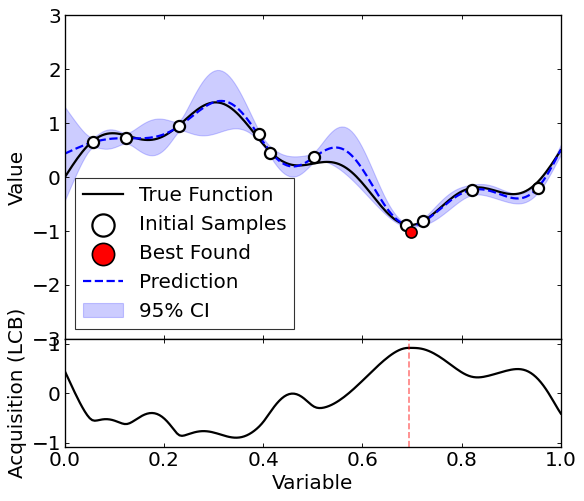

--------------------------------------------------
Optimization Finished using LCB.
Global Best Found: y = -1.019506


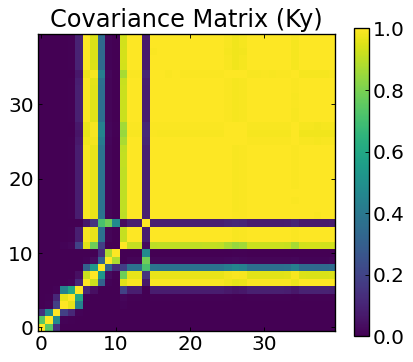

In [7]:
# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
# Hyperparameters
gamma = 65.0
noise_std = 0.05
noise_var = noise_std ** 2

# Domain settings
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# Optimization Loop Settings
n_init = 10
n_iter = 30
xi = 0.01

# Grid for plotting ONLY (No longer used for search loop)
X_grid = np.linspace(0, 1, 200)[:, None]

# --- Acquisition Function Selection ---
STRATEGY = "LCB"  # Options: "EI" or "LCB"

if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
# Generate samples and observations
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
X_train = X_train[np.argsort(X_train[:, 0])]
y_train = lib_debug.test_1D(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep copy for plotting
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x (approx)'}")
print("-" * 50)

for i in range(n_iter):
    
    # 1. Fit GP (Calculate Ky_inv)
    Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

    # 2. Find Next Point (Continuous Optimization instead of Grid Search)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # 3. Evaluate True Function
    # x_new comes out as (dims,), need reshape for evaluation
    y_new = lib_debug.test_1D(x_new.reshape(1, -1)) + np.random.normal(0, noise_std, (1, 1))

    # 4. Update Data
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])
    
    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]:.2f}]")


# -------------------- 5. Final Calculation & Visualization --------------------
# Re-fit GP with all data
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# Get predictions and acquisition values for plotting
# (Here we still use X_grid to draw the curves)
mu_list = []
sigma_list = []
acq_final_list = []

for x in X_grid:
    m, s = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(m)
    sigma_list.append(s)
    acq_final_list.append(acq_func(kernel, x, X_train, y_train, Ky_inv, gamma, **acq_params))

mu_post = np.array(mu_list)
s_post = np.array(sigma_list)
acq_final = np.array(acq_final_list)

# Identify Best Point
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

# Visualization
lib_debug.plot_gp_results(
    X_grid=X_grid,
    true_func=lib_debug.test_1D,
    X_init=X_init_plot,
    y_init=y_init_plot,
    best_x=best_x,
    best_y=best_y,
    mu=mu_post,
    sigma=s_post,
    acq_values=acq_final,
    strategy_name=STRATEGY
)

print("-" * 50)
print(f"Optimization Finished using {STRATEGY}.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, gamma)
lib_debug.plot_covariance_matrix(K_final)

--- Strategy Selected: EI ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x (approx)
---------------------------------------------------------------------------
1     | 14.693512   | 21.520697   | 0.1000   | [32.00, 6.50]
2     | 14.693512   | 19.872660   | 0.1000   | [-15.02, -32.00]
3     | 14.693512   | 19.833644   | 0.1000   | [-32.00, 10.02]
4     | 10.899633   | 10.899633   | 0.1000   | [3.28, -2.43]
5     | 10.899633   | 20.080725   | 0.1000   | [18.09, 32.00]
6     | 10.899633   | 21.356612   | 0.1000   | [20.50, 5.51]
7     | 10.899633   | 20.307831   | 0.1000   | [-28.12, 32.00]
8     | 10.899633   | 20.036607   | 0.1000   | [-15.92, -13.24]
9     | 10.899633   | 21.079524   | 0.1000   | [-26.26, -32.00]
10    | 10.899633   | 21.217726   | 0.1000   | [-4.33, -32.00]
11    | 10.899633   | 21.500712   | 0.1000   | [-7.18, 25.50]
12    | 10.899633   | 21.607657   | 0.1000   | [17.36, 20.72]
13    | 10.899633   | 21.005240 

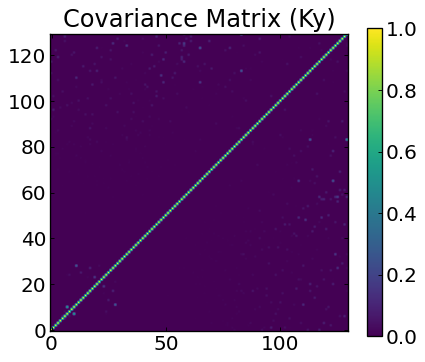

In [8]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
dims = 2
lower_bounds = [-32, -32]
upper_bounds = [32, 32]

# Initial Gamma
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 30
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
y_train = lib_debug.ackley_2d(X_train).reshape(-1, 1)

# NOTE: No Grid creation here anymore! (We use continuous optimization)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x (approx)'}")
print("-" * 75)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function (Find Next Point) ---
    # Instead of Grid Search, we use continuous optimization (L-BFGS-B)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # --- Step E: Evaluate True Function ---
    y_new = lib_debug.ackley_2d(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | [{x_new[0]:.2f}, {x_new[1]:.2f}]")

# -------------------- 5. Final Result & Visualization --------------------
best_idx_final = np.argmin(y_train)
print("-" * 75)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
print(f"At location: x = {X_train[best_idx_final]}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)

--- Strategy Selected: EI ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x (approx)
---------------------------------------------------------------------------
1     | 1.041553   | 4.999871   | 1.0000   | [94.40, -65.53]
2     | 1.041553   | 1.707889   | 1.0000   | [26.52, 52.68]
3     | 1.041553   | 1.828435   | 1.0000   | [63.38, -10.76]
4     | 1.041553   | 3.574074   | 1.0000   | [-48.23, 94.70]
5     | 1.041553   | 4.507492   | 1.0000   | [93.92, -40.47]
6     | 1.041553   | 3.474109   | 1.0000   | [95.72, -23.85]
7     | 1.041553   | 1.293754   | 1.0000   | [-32.96, 10.77]
8     | 1.041553   | 2.421219   | 1.0000   | [-2.87, 44.08]
9     | 1.041553   | 2.495877   | 1.0000   | [-35.09, -51.99]
10    | 1.041553   | 2.701781   | 1.0000   | [-3.26, 53.22]
11    | 1.041553   | 4.460692   | 1.0000   | [-60.89, -96.40]
12    | 1.041553   | 1.464255   | 1.0000   | [-16.75, 25.13]
13    | 1.041553   | 4.663238   | 1.0000   | [79.88

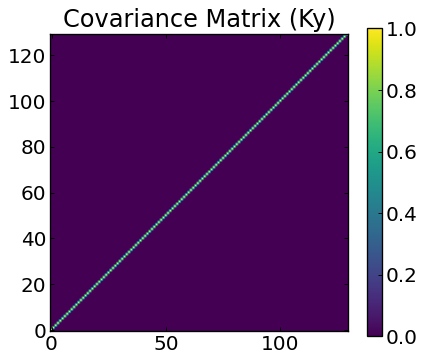

In [10]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
dims = 2
lower_bounds = [-100, -100]
upper_bounds = [100, 100]

# Initial Gamma
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 30
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
y_train = lib_debug.griewank_2d(X_train).reshape(-1, 1)

# NOTE: No Grid creation here anymore! (We use continuous optimization)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x (approx)'}")
print("-" * 75)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function (Find Next Point) ---
    # Instead of Grid Search, we use continuous optimization (L-BFGS-B)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # --- Step E: Evaluate True Function ---
    y_new = lib_debug.griewank_2d(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | [{x_new[0]:.2f}, {x_new[1]:.2f}]")

# -------------------- 5. Final Result & Visualization --------------------
best_idx_final = np.argmin(y_train)
print("-" * 75)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
print(f"At location: x = {X_train[best_idx_final]}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)

--- Strategy: EI | Dimensions: 30 ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x vector
------------------------------------------------------------------------------------------
1     | 20.292482   | 21.110565   | 1.0000   | [-10.75,  24.68,  17.88,  12.66,  17.26,  19.31,   9.64,  10.  ,  19.96,
 -15.82, -28.82,   4.  ,  -0.45, -16.21, -10.29,  11.45,  30.91,  15.76,
  -7.81, -25.23,   5.  ,  25.  ,  10.18, -31.85, -11.94,   8.34,  17.87,
 -28.57, -22.59,  26.52]
2     | 20.292482   | 20.881082   | 1.0000   | [ -2.25, -31.32,  16.45,  11.03,   5.02, -27.67,   1.5 ,  -9.28,  13.69,
 -15.87, -17.27,  -0.61,  -8.9 ,  11.23, -24.11,   7.08,   4.15,  -7.17,
 -25.7 , -31.56, -30.16,  14.28,  -3.79,  -9.52,   1.11,  11.92,   6.31,
  26.84,  22.18,  12.09]
3     | 20.292482   | 21.060115   | 1.0000   | [ 23.04,   9.68,  28.99,  15.92, -18.72, -26.9 ,  14.85,  14.04,   1.56,
 -24.23,   5.67,  20.02,  17.1 , -25.13,  -6.64, -15.69,   

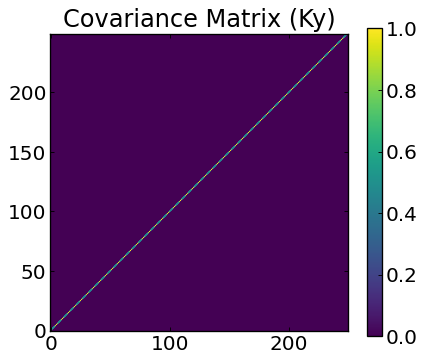

In [12]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings (N-Dimensional) --------------------
dims = 30  # ★ここを変えるだけで次元数を変更可能
bound_val = 32.0

# numpy配列で境界を定義 (dimsの数だけ拡張)
lower_bounds = np.full(dims, -bound_val)
upper_bounds = np.full(dims, bound_val)

# Initial Gamma & Noise
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 5 * dims  # 次元数に応じて初期点数を増やすのが一般的
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy: {STRATEGY} | Dimensions: {dims} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)

y_train = lib_debug.ackley_nd(X_train).reshape(-1, 1)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
# ログヘッダー調整
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x vector'}")
print("-" * 90)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function ---
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )

    # --- Step E: Evaluate True Function (N-D) ---
    y_new = lib_debug.ackley_nd(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)

    x_str = np.array2string(x_new, precision=2, separator=', ', suppress_small=True)

    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | {x_str}")

# -------------------- 5. Final Result --------------------
best_idx_final = np.argmin(y_train)
print("-" * 90)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
with np.printoptions(precision=4, suppress=True):
    print(f"At location: x = {X_train[best_idx_final]}")

K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)

--- Strategy: EI | Dimensions: 30 ---
--- Starting Optimization Loop (100 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x vector
------------------------------------------------------------------------------------------
1     | 2.446166   | 3.481053   | 1.0000   | [ -0.83,  -8.93,  -8.12,   9.43,   9.79, -30.82, -22.95,  31.45, -13.45,
  28.86,   3.03,  11.89,  23.19, -26.81, -20.49,  17.56, -20.13,  30.08,
 -21.9 ,   6.03,   9.11,   8.08,  -3.91,  21.07,   5.3 ,  18.42,  20.23,
  18.14,  10.63,  18.04]
2     | 2.446166   | 3.366635   | 1.0000   | [  9.42,  30.18,  28.82, -26.04,   5.04, -20.83,  -7.69, -14.34,  30.66,
  -3.48,  -7.96, -14.71,  -9.47,   9.15,  -7.34,  -7.05, -27.7 ,  21.9 ,
  12.23, -14.7 ,  14.18,   2.4 ,  -5.79,  -2.66, -25.39, -29.49,  13.19,
  -9.5 ,  24.74, -21.81]
3     | 2.446166   | 3.823465   | 1.0000   | [-11.54,  25.09,  18.93, -28.74, -22.5 ,  31.24,  -2.06,  20.45,   1.94,
 -28.89,  29.89,  19.57, -21.72,   2.28,  27.91,   1.71,  12.5 , 

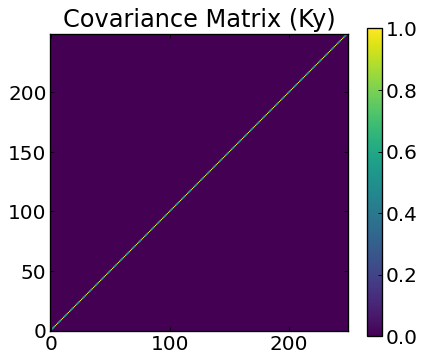

In [13]:
import numpy as np
from scipy.optimize import minimize
import lib_debug

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings (N-Dimensional) --------------------
dims = 30  # ★ここを変えるだけで次元数を変更可能
bound_val = 32.0

# numpy配列で境界を定義 (dimsの数だけ拡張)
lower_bounds = np.full(dims, -bound_val)
upper_bounds = np.full(dims, bound_val)

# Initial Gamma & Noise
current_gamma = 1.0
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 5 * dims  # 次元数に応じて初期点数を増やすのが一般的
n_iter = 100

# Strategy Selection
STRATEGY = "EI" 
if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy: {STRATEGY} | Dimensions: {dims} ---")

# -------------------- 3. Initialization --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)

y_train = lib_debug.griewank_nd(X_train).reshape(-1, 1)

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
# ログヘッダー調整
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x vector'}")
print("-" * 90)

for i in range(n_iter):

    # --- Step A: Optimize Hyperparameters (Gamma) ---
    res_hyp = minimize(
        lib_debug.negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], 
        method='L-BFGS-B'
    )
    if res_hyp.success:
        current_gamma = res_hyp.x[0]

    # --- Step B: Fit GP (Calculate Ky_inv) ---
    Ky_inv = lib_debug.fit_gp(kernel, X_train, current_gamma, noise_var)

    # --- Step C & D: Optimize Acquisition Function ---
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, acq_params
    )

    # --- Step E: Evaluate True Function (N-D) ---
    y_new = lib_debug.griewank_nd(x_new.reshape(1, -1))

    # --- Step F: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)

    x_str = np.array2string(x_new, precision=2, separator=', ', suppress_small=True)

    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | {x_str}")

# -------------------- 5. Final Result --------------------
best_idx_final = np.argmin(y_train)
print("-" * 90)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
with np.printoptions(precision=4, suppress=True):
    print(f"At location: x = {X_train[best_idx_final]}")

K_final = kernel(X_train, X_train, current_gamma)
lib_debug.plot_covariance_matrix(K_final)